In [1]:
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.models as models
import torchvision.transforms as transforms
import torch.nn.functional as F
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from pathlib import Path
from torch.utils.data import Dataset
from PIL import Image
import os

In [2]:
DATA_ROOT = r'/kaggle/input/kitti-dataset/depth_selection/val_selection_cropped'
IMG_DIR = os.path.join(DATA_ROOT, 'image')
DEPTH_GT_DIR = os.path.join(DATA_ROOT, 'groundtruth_depth')

In [3]:
class DepthEstimationNet(nn.Module):
    def __init__(self):
        super(DepthEstimationNet, self).__init__()
        resnet = models.resnet50(pretrained=True)
        self.encoder = nn.Sequential(*list(resnet.children())[:-2]) 

        self.decoder = nn.Sequential(
            nn.Conv2d(2048, 1024, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(size=(32, 40), mode='bilinear', align_corners=True),  
            nn.Conv2d(1024, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(size=(64, 80), mode='bilinear', align_corners=True), 
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(size=(128, 160), mode='bilinear', align_corners=True), 
            nn.Conv2d(256, 1, kernel_size=1)  # Single-channel depth map
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [4]:
transform_rgb = transforms.Compose([
    transforms.Resize((228, 304)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform_depth = transforms.Compose([
    transforms.Resize((128, 160)),  
    transforms.ToTensor()
])

In [5]:

class NYUDepthDataset(Dataset):
    def __init__(self, img_dir, depth_dir, transform_rgb, transform_depth, target_size=(160, 160)):
        self.img_dir = Path(img_dir)
        self.depth_dir = Path(depth_dir)
        self.transform_rgb = transform_rgb
        self.transform_depth = transform_depth
        self.image_filenames = sorted(os.listdir(img_dir))
        self.target_size = target_size

    def __len__(self):
        return len(self.image_filenames)
    
    def __getitem__(self, idx):

        img_name = self.image_filenames[idx]
        rgb_path = os.path.join(self.img_dir, img_name)
        depth_img_name = img_name.replace("image", "groundtruth_depth", 1)  
        depth_path = os.path.join(self.depth_dir, depth_img_name)

        if not os.path.exists(depth_path):
            raise FileNotFoundError(f"Depth file not found: {depth_path}")

        rgb = Image.open(rgb_path).convert('RGB')
        depth = Image.open(depth_path)

        rgb = rgb.resize(self.target_size)
        depth = depth.resize(self.target_size)
        rgb = self.transform_rgb(rgb)
        depth = self.transform_depth(depth)
        depth = np.array(depth).astype(np.float32)
        depth = torch.from_numpy(depth).unsqueeze(0)  

        return rgb, depth
    


In [6]:
target_size = (128, 160)

full_dataset = NYUDepthDataset(IMG_DIR, DEPTH_GT_DIR, transform_rgb, transform_depth, target_size)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DepthEstimationNet().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 182MB/s] 


In [8]:
from tqdm import tqdm

EPOCHS = 50

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)

    for rgb, depth in train_loader_tqdm:
        rgb, depth = rgb.to(device), depth.to(device)

        optimizer.zero_grad()
        outputs = model(rgb)
        loss = criterion(outputs, depth)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        train_loader_tqdm.set_postfix(loss=loss.item())

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS}, Avg Loss: {avg_loss:.4f}")

    # Save model every 5 epochs
    if (epoch + 1) % 5 == 0:
        checkpoint_path = f'depth_model_epoch_{epoch+1}.pth'
        torch.save(model.state_dict(), checkpoint_path)
        print(f"Saved model at {checkpoint_path}")


Epoch 1/50:   0%|          | 0/200 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([4, 1, 1, 128, 160])) that is different to the input size (torch.Size([4, 1, 128, 160])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 1/50, Avg Loss: 999839.6428


Epoch 2/50, Avg Loss: 904659.2584


Epoch 3/50, Avg Loss: 885305.3794


Epoch 4/50, Avg Loss: 869995.7269


...

Epoch 46/50, Avg Loss: 779798.5866


Epoch 47/50, Avg Loss: 774272.2214


Epoch 48/50, Avg Loss: 777001.1359


Epoch 49/50, Avg Loss: 776594.7459


Epoch 50/50, Avg Loss: 770615.6522
Saved model at depth_model_epoch_50.pth


In [9]:
def infer_and_visualize(rgb_tensor, pred_depth, gt_depth):
    rgb = rgb_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    rgb = (rgb * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
    rgb = np.clip(rgb, 0, 1)

    pred_depth = pred_depth.squeeze().cpu().numpy()
    gt_depth = gt_depth.squeeze().cpu().numpy()

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(rgb)
    plt.title("RGB")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(pred_depth, cmap='inferno')
    plt.title("Predicted Depth")
    plt.axis('off')
    plt.colorbar()

    plt.subplot(1, 3, 3)
    plt.imshow(gt_depth, cmap='inferno')
    plt.title("Ground Truth Depth")
    plt.axis('off')
    plt.colorbar()
    plt.show()

In [10]:
from PIL import Image
import torchvision.transforms as transforms

# Use same transform as training
transform_rgb = transforms.Compose([
    transforms.Resize((228, 304)),  # same resize used before
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [11]:
# Load custom image
img_path = '/kaggle/input/dog-bike-car/dog_bike_car.jpg'  # update this
img = Image.open(img_path).convert('RGB')
img = transform_rgb(img).unsqueeze(0).to(device)  # shape: [1, 3, H, W]

In [12]:
model = DepthEstimationNet().to(device)
model.load_state_dict(torch.load('depth_model_epoch_50.pth'))
model.eval()

/tmp/ipykernel_55/2188121164.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('depth_model_epoch_50.pth'))


DepthEstimationNet(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): 

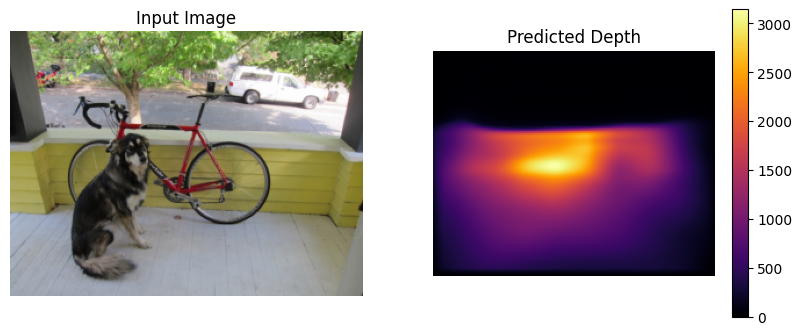

In [13]:
with torch.no_grad():
    pred = model(img)

# Convert and visualize
import matplotlib.pyplot as plt
import numpy as np

rgb_np = img.squeeze().permute(1, 2, 0).cpu().numpy()
rgb_np = (rgb_np * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
rgb_np = np.clip(rgb_np, 0, 1)

pred_np = pred.squeeze().cpu().numpy()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(rgb_np)
plt.title("Input Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(pred_np, cmap='inferno')
plt.title("Predicted Depth")
plt.axis('off')
plt.colorbar()
plt.show()